# H11: Platform-Deconfounded LDA Analysis

H10's centroid-axis LDA (C/C→T/T in 17 z-scored morphological features) shows rho=0.65 dosage trend
(p=0.016), but deep analysis reveals critical platform contamination:
- Cosine similarity All vs PC-only axis = **0.232** (nearly orthogonal)
- LOO cross-validation dosage rho collapses to **0.10, p=0.74**
- Two CODEX T/T samples drive the extreme positive end

This notebook applies 5 complementary deconfounding strategies, capped by permutation testing.

In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, mannwhitneyu
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from data_utils import (
    load_all_data, build_feature_matrix, platform_diagnostic,
    residualize_platform, assign_region_by_distance, extract_sample_id,
    GENO_ORDER, GENO_PALETTE, CODEX_SAMPLES, PHENOCYCLER_SAMPLES,
    GENOTYPE_MAP, EXCLUDE_SAMPLES, PROJECT,
    setup_style, save_figure, save_table,
)

setup_style()
rng = np.random.default_rng(42)

# Load annotation-level data and build feature matrix
df = load_all_data()
feat = build_feature_matrix(df)
morph_cols = [c for c in feat.columns if c not in ('Genotype', 'Platform')]
print(f'Samples: {len(feat)}, Features: {len(morph_cols)}')
print(f'Genotype distribution:\n{feat["Genotype"].value_counts()}')
feat[morph_cols].describe().round(3)

Samples: 13, Features: 20
Genotype distribution:
Genotype
C/T    6
C/C    4
T/T    3
Name: count, dtype: int64


,Follicle_density,Follicle_norm_density,PALS_density,PALS_norm_density,RedPulp_density,Trabeculae_density,Trabeculae_norm_density,Follicle_count,Follicle_total_area,Follicle_mean_area,Follicle_fraction,PALS_fraction,RedPulp_fraction,Trabeculae_fraction,WP_fraction,Follicle_PALS_ratio,Vessel_median_area,Vessel_median_circularity,Vessel_median_solidity,Vessel_median_elongation
count,13.000,13.000,13.000,13.000,13.000,13.000,13.000,13.000,1.300000e+01,13.000,13.000,13.000,13.000,13.000,13.000,13.000,13.000,10.000,10.000,10.000
mean,242.223,0.722,295.774,0.955,365.608,333.345,0.976,146.385,8.495069e+06,60740.367,0.090,0.066,0.810,0.035,0.155,2.528,47.386,0.387,0.785,1.734
std,135.391,0.514,146.990,0.827,116.883,354.354,1.075,124.388,9.651371e+06,40920.360,0.060,0.047,0.082,0.015,0.086,3.500,10.930,0.057,0.031,0.036
min,65.384,0.265,37.304,0.083,153.498,21.244,0.072,7.000,2.485137e+05,11166.764,0.014,0.016,0.617,0.015,0.046,0.297,29.230,0.266,0.717,1.684
25%,124.742,0.319,193.491,0.573,295.507,127.584,0.312,30.000,1.485560e+06,35853.970,0.039,0.032,0.775,0.024,0.099,0.639,41.250,0.393,0.784,1.705
50%,226.978,0.695,304.436,0.778,374.067,157.400,0.394,147.000,4.339624e+06,49518.683,0.069,0.050,0.820,0.031,0.146,1.221,48.355,0.412,0.796,1.734
75%,323.867,0.828,357.702,1.030,441.249,418.507,1.098,220.000,1.504754e+07,81139.324,0.119,0.089,0.861,0.042,0.188,1.940,52.600,0.418,0.804,1.756
max,458.717,2.103,533.329,3.475,594.439,1196.680,3.665,406.000,3.294257e+07,160696.671,0.191,0.165,0.925,0.071,0.356,10.530,67.030,0.430,0.814,1.791


## Helper functions

In [2]:
DOSAGE_MAP = {'C/C': 0, 'C/T': 1, 'T/T': 2}
PLAT_MARKERS = {'Phenocycler': 'o', 'CODEX': 's'}
PLAT_COLORS = {'Phenocycler': 'steelblue', 'CODEX': 'coral'}


def centroid_axis(X, genotypes, g_from='C/C', g_to='T/T'):
    """Compute unit vector from g_from centroid to g_to centroid."""
    mask_from = np.array([g == g_from for g in genotypes])
    mask_to = np.array([g == g_to for g in genotypes])
    c_from = X[mask_from].mean(axis=0)
    c_to = X[mask_to].mean(axis=0)
    axis = c_to - c_from
    return axis / np.linalg.norm(axis)


def dosage_rho(projections, genotypes):
    """Spearman correlation of projections with ordinal genotype."""
    dosage = np.array([DOSAGE_MAP[g] for g in genotypes])
    return spearmanr(dosage, projections)


def platform_rho(projections, platforms):
    """Spearman correlation of projections with platform (CODEX=1)."""
    plat_code = np.array([1 if p == 'CODEX' else 0 for p in platforms])
    return spearmanr(plat_code, projections)


def loo_dosage_rho(X, genotypes):
    """Leave-one-out cross-validation: build axis without held-out sample, project it."""
    n = len(X)
    loo_projs = np.zeros(n)
    for i in range(n):
        mask = np.ones(n, dtype=bool)
        mask[i] = False
        axis_i = centroid_axis(X[mask], genotypes[mask])
        loo_projs[i] = X[i] @ axis_i
    return dosage_rho(loo_projs, genotypes)


def cosine_sim(a, b):
    """Cosine similarity between two vectors."""
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))


def plot_projection(proj_df, title, ax=None):
    """Scatter plot of projections by genotype, styled by platform."""
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 5))
    for geno in GENO_ORDER:
        for plat, marker in PLAT_MARKERS.items():
            sub = proj_df[(proj_df['Genotype'] == geno) & (proj_df['Platform'] == plat)]
            if sub.empty:
                continue
            ax.scatter([geno] * len(sub), sub['Projection'],
                       c=[GENO_PALETTE[geno]], marker=marker, s=80,
                       edgecolors='black', linewidths=0.5,
                       label=plat if geno == GENO_ORDER[0] else '')
            for _, row in sub.iterrows():
                ax.annotate(row['Sample'], (geno, row['Projection']),
                           fontsize=7, alpha=0.7, xytext=(8, 0),
                           textcoords='offset points')
    ax.set_xlabel('Genotype')
    ax.set_ylabel('Projection onto C/C→T/T axis')
    ax.set_title(title)
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(title='Platform')
    return ax

## Section 1: Baseline Diagnostic

In [3]:
# Prepare scaled features — fill NaN with column median (3 CODEX samples lack vessel morphology)
feat_filled = feat.copy()
for col in morph_cols:
    if feat_filled[col].isna().any():
        feat_filled[col] = feat_filled[col].fillna(feat_filled[col].median())
        print(f'  Imputed NaN in {col} with median={feat[col].median():.3f}')

X_raw = feat_filled[morph_cols].values.astype(float)
scaler_all = StandardScaler()
X_all = scaler_all.fit_transform(X_raw)
genos_all = feat_filled['Genotype'].astype(str).values
plats_all = feat_filled['Platform'].values
samples_all = feat_filled.index.values

# PC-only subset
pc_mask = feat_filled['Platform'] == 'Phenocycler'
X_pc_raw = feat_filled.loc[pc_mask, morph_cols].values.astype(float)
scaler_pc = StandardScaler()
X_pc = scaler_pc.fit_transform(X_pc_raw)
genos_pc = feat_filled.loc[pc_mask, 'Genotype'].astype(str).values
plats_pc = feat_filled.loc[pc_mask, 'Platform'].values
samples_pc = feat_filled.index[pc_mask].values

# Baseline centroid axis (all samples)
axis_all = centroid_axis(X_all, genos_all)
projs_all = X_all @ axis_all

# PC-only centroid axis
axis_pc = centroid_axis(X_pc, genos_pc)

# Metrics
rho_d, p_d = dosage_rho(projs_all, genos_all)
rho_pl, p_pl = platform_rho(projs_all, plats_all)
cos_all_pc = cosine_sim(axis_all, axis_pc)
rho_loo, p_loo = loo_dosage_rho(X_all, genos_all)

# Platform variance fraction: R^2 of projection ~ platform
plat_code = np.array([1 if p == 'CODEX' else 0 for p in plats_all])
ss_total = np.sum((projs_all - projs_all.mean())**2)
fitted = np.where(plat_code == 1, projs_all[plat_code == 1].mean(), projs_all[plat_code == 0].mean())
r2_platform = 1 - np.sum((projs_all - fitted)**2) / ss_total

baseline_metrics = pd.DataFrame([{
    'Metric': 'Baseline (All)',
    'rho_dosage': rho_d, 'p_dosage': p_d,
    'rho_platform': rho_pl, 'p_platform': p_pl,
    'cos_vs_pc_axis': cos_all_pc,
    'rho_LOO': rho_loo, 'p_LOO': p_loo,
    'R2_platform': r2_platform,
    'n_samples': len(X_all),
}])
print(baseline_metrics.to_string(index=False))

  Imputed NaN in Vessel_median_circularity with median=0.412
  Imputed NaN in Vessel_median_solidity with median=0.796
  Imputed NaN in Vessel_median_elongation with median=1.734
        Metric  rho_dosage  p_dosage  rho_platform  p_platform  cos_vs_pc_axis  rho_LOO    p_LOO  R2_platform  n_samples
Baseline (All)     0.47842   0.09817      0.464835    0.109499       -0.104033 0.129941 0.672219       0.2856         13


Saved: analysis/figures/H11_baseline_diagnostic.png
Saved: analysis/tables/H11_baseline_diagnostic.csv


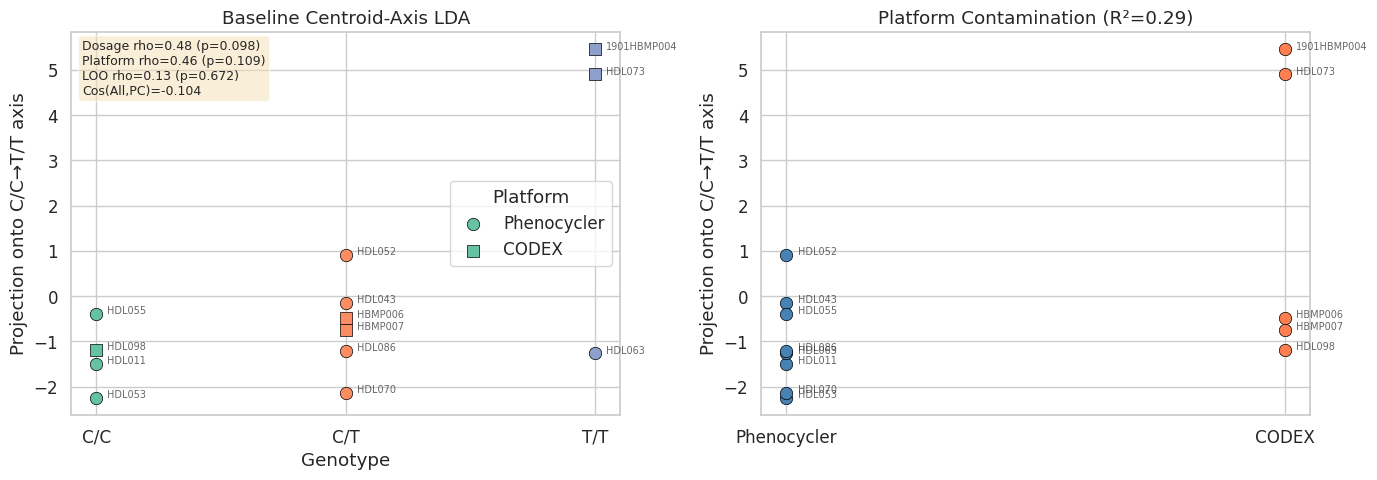

In [4]:
# Baseline diagnostic figure
proj_df_base = pd.DataFrame({
    'Sample': samples_all, 'Projection': projs_all,
    'Genotype': genos_all, 'Platform': plats_all,
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: projection by genotype
plot_projection(proj_df_base, 'Baseline Centroid-Axis LDA', ax=axes[0])
axes[0].text(0.02, 0.98,
    f'Dosage rho={rho_d:.2f} (p={p_d:.3f})\n'
    f'Platform rho={rho_pl:.2f} (p={p_pl:.3f})\n'
    f'LOO rho={rho_loo:.2f} (p={p_loo:.3f})\n'
    f'Cos(All,PC)={cos_all_pc:.3f}',
    transform=axes[0].transAxes, fontsize=9, va='top',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Right: projection by platform
for plat, color in PLAT_COLORS.items():
    sub = proj_df_base[proj_df_base['Platform'] == plat]
    axes[1].scatter(sub['Platform'], sub['Projection'], c=color,
                    s=80, edgecolors='black', linewidths=0.5)
    for _, row in sub.iterrows():
        axes[1].annotate(row['Sample'], (row['Platform'], row['Projection']),
                        fontsize=7, alpha=0.7, xytext=(8, 0),
                        textcoords='offset points')
axes[1].set_ylabel('Projection onto C/C→T/T axis')
axes[1].set_title(f'Platform Contamination (R²={r2_platform:.2f})')

fig.tight_layout()
save_figure(fig, 'H11_baseline_diagnostic')
save_table(baseline_metrics, 'H11_baseline_diagnostic')
plt.show()

## Section 2: Approach A — Platform Residualization

In [5]:
# Residualize features (use NaN-filled data)
feat_resid = residualize_platform(feat_filled, morph_cols)
X_resid_raw = feat_resid[morph_cols].values.astype(float)
scaler_resid = StandardScaler()
X_resid = scaler_resid.fit_transform(X_resid_raw)

axis_resid = centroid_axis(X_resid, genos_all)
projs_resid = X_resid @ axis_resid

rho_d_r, p_d_r = dosage_rho(projs_resid, genos_all)
rho_pl_r, p_pl_r = platform_rho(projs_resid, plats_all)
cos_resid_pc = cosine_sim(axis_resid, axis_pc)
rho_loo_r, p_loo_r = loo_dosage_rho(X_resid, genos_all)

print(f'Approach A — Residualized:')
print(f'  Dosage rho={rho_d_r:.3f} (p={p_d_r:.3f})')
print(f'  Platform rho={rho_pl_r:.3f} (p={p_pl_r:.3f})')
print(f'  Cos(Resid, PC-only)={cos_resid_pc:.3f}')
print(f'  LOO rho={rho_loo_r:.3f} (p={p_loo_r:.3f})')

Approach A — Residualized:
  Dosage rho=0.496 (p=0.085)
  Platform rho=-0.169 (p=0.581)
  Cos(Resid, PC-only)=0.056
  LOO rho=0.180 (p=0.556)


Saved: analysis/figures/H11_residualized_projection.png


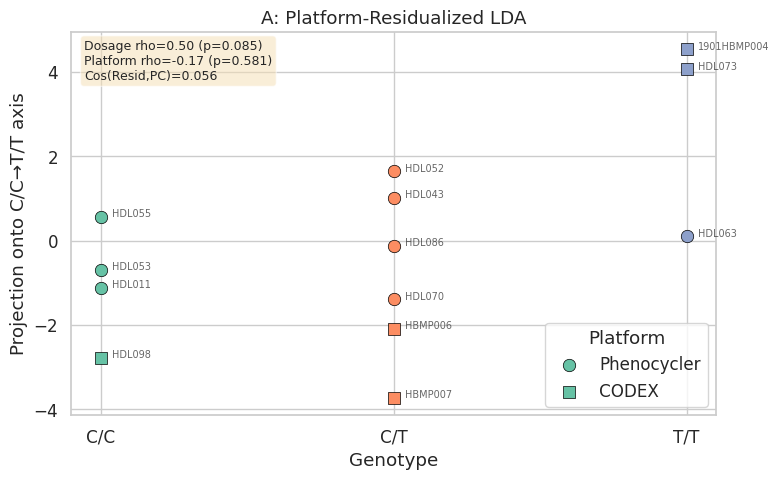

In [6]:
proj_df_resid = pd.DataFrame({
    'Sample': samples_all, 'Projection': projs_resid,
    'Genotype': genos_all, 'Platform': plats_all,
})

fig, ax = plt.subplots(figsize=(8, 5))
plot_projection(proj_df_resid, 'A: Platform-Residualized LDA', ax=ax)
ax.text(0.02, 0.98,
    f'Dosage rho={rho_d_r:.2f} (p={p_d_r:.3f})\n'
    f'Platform rho={rho_pl_r:.2f} (p={p_pl_r:.3f})\n'
    f'Cos(Resid,PC)={cos_resid_pc:.3f}',
    transform=ax.transAxes, fontsize=9, va='top',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
fig.tight_layout()
save_figure(fig, 'H11_residualized_projection')
plt.show()

## Section 3: Approach B — PC-Only LDA + CODEX Validation

In [7]:
# Build axis from PC-only, project all samples using PC-only standardization
# Standardize all samples using PC-only mean/std
X_all_pcstd = (X_raw - scaler_pc.mean_) / scaler_pc.scale_
projs_pcaxis = X_all_pcstd @ axis_pc

rho_d_pc, p_d_pc = dosage_rho(projs_pcaxis, genos_all)
rho_pl_pc, p_pl_pc = platform_rho(projs_pcaxis, plats_all)
rho_loo_pc, p_loo_pc = loo_dosage_rho(X_pc, genos_pc)  # LOO within PC only

print(f'Approach B — PC-Only axis, all samples projected:')
print(f'  Dosage rho={rho_d_pc:.3f} (p={p_d_pc:.3f})')
print(f'  Platform rho={rho_pl_pc:.3f} (p={p_pl_pc:.3f})')
print(f'  LOO rho (PC-only)={rho_loo_pc:.3f} (p={p_loo_pc:.3f})')

Approach B — PC-Only axis, all samples projected:
  Dosage rho=-0.109 (p=0.722)
  Platform rho=-0.592 (p=0.033)
  LOO rho (PC-only)=nan (p=nan)


/tmp/ipykernel_558712/814203141.py:11: RuntimeWarning: Mean of empty slice.
  c_to = X[mask_to].mean(axis=0)
/usr/lib/python3/dist-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Saved: analysis/figures/H11_pc_axis_codex_validation.png


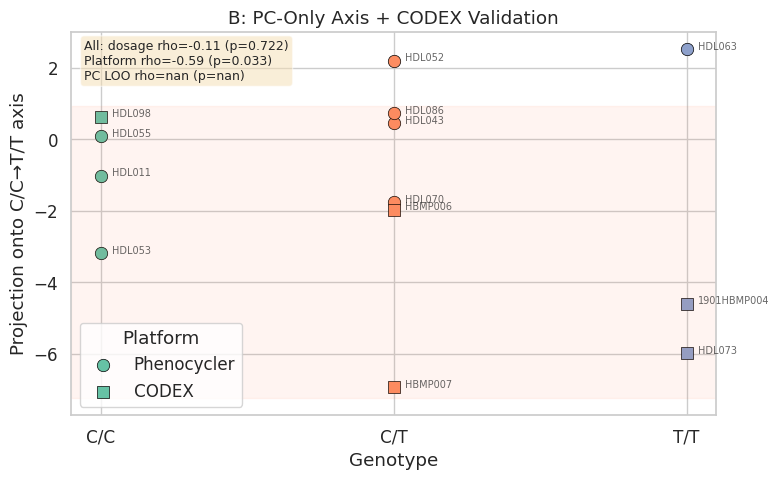

In [8]:
proj_df_pcaxis = pd.DataFrame({
    'Sample': samples_all, 'Projection': projs_pcaxis,
    'Genotype': genos_all, 'Platform': plats_all,
})

fig, ax = plt.subplots(figsize=(8, 5))
plot_projection(proj_df_pcaxis, 'B: PC-Only Axis + CODEX Validation', ax=ax)
# Highlight CODEX samples
codex_sub = proj_df_pcaxis[proj_df_pcaxis['Platform'] == 'CODEX']
ax.axhspan(codex_sub['Projection'].min() - 0.3, codex_sub['Projection'].max() + 0.3,
           alpha=0.08, color='coral', label='CODEX range')
ax.text(0.02, 0.98,
    f'All: dosage rho={rho_d_pc:.2f} (p={p_d_pc:.3f})\n'
    f'Platform rho={rho_pl_pc:.2f} (p={p_pl_pc:.3f})\n'
    f'PC LOO rho={rho_loo_pc:.2f} (p={p_loo_pc:.3f})',
    transform=ax.transAxes, fontsize=9, va='top',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
fig.tight_layout()
save_figure(fig, 'H11_pc_axis_codex_validation')
plt.show()

## Section 4: Approach C — Platform-Clean Feature Selection

In [9]:
# Identify features indistinguishable between platforms (p > 0.1)
plat_diag = platform_diagnostic(feat_filled, morph_cols)
clean_features = plat_diag.loc[plat_diag['p'] > 0.1, 'Feature'].tolist()
print(f'Platform-clean features ({len(clean_features)}/{len(morph_cols)}):')
print(clean_features)

if len(clean_features) >= 2:
    X_clean_raw = feat_filled[clean_features].values.astype(float)
    scaler_clean = StandardScaler()
    X_clean = scaler_clean.fit_transform(X_clean_raw)

    axis_clean = centroid_axis(X_clean, genos_all)
    projs_clean = X_clean @ axis_clean

    # PC-only axis on clean features for cosine comparison
    X_clean_pc = scaler_clean.transform(feat_filled.loc[pc_mask, clean_features].values.astype(float))
    axis_clean_pc = centroid_axis(X_clean_pc, genos_pc)

    rho_d_c, p_d_c = dosage_rho(projs_clean, genos_all)
    rho_pl_c, p_pl_c = platform_rho(projs_clean, plats_all)
    cos_clean_pc = cosine_sim(axis_clean, axis_clean_pc)
    rho_loo_c, p_loo_c = loo_dosage_rho(X_clean, genos_all)

    print(f'\nApproach C — Clean features:')
    print(f'  Dosage rho={rho_d_c:.3f} (p={p_d_c:.3f})')
    print(f'  Platform rho={rho_pl_c:.3f} (p={p_pl_c:.3f})')
    print(f'  Cos(Clean, Clean-PC)={cos_clean_pc:.3f}')
    print(f'  LOO rho={rho_loo_c:.3f} (p={p_loo_c:.3f})')
else:
    print('Fewer than 2 clean features — skipping Approach C')
    projs_clean = None

Platform-clean features (15/20):
['PALS_density', 'PALS_norm_density', 'RedPulp_density', 'Trabeculae_density', 'Trabeculae_norm_density', 'Follicle_mean_area', 'Follicle_fraction', 'PALS_fraction', 'RedPulp_fraction', 'Trabeculae_fraction', 'WP_fraction', 'Follicle_PALS_ratio', 'Vessel_median_circularity', 'Vessel_median_solidity', 'Vessel_median_elongation']

Approach C — Clean features:
  Dosage rho=0.499 (p=0.083)
  Platform rho=0.211 (p=0.488)
  Cos(Clean, Clean-PC)=-0.003
  LOO rho=0.183 (p=0.549)


Saved: analysis/figures/H11_clean_feature_lda.png


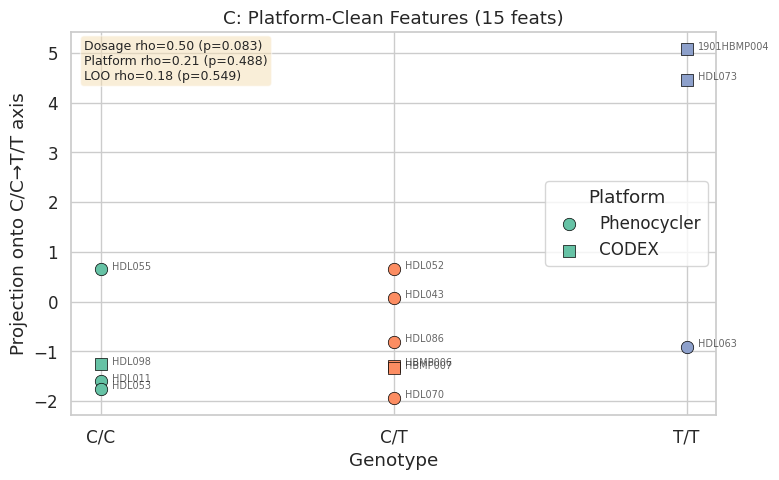

In [10]:
if projs_clean is not None:
    proj_df_clean = pd.DataFrame({
        'Sample': samples_all, 'Projection': projs_clean,
        'Genotype': genos_all, 'Platform': plats_all,
    })
    fig, ax = plt.subplots(figsize=(8, 5))
    plot_projection(proj_df_clean,
        f'C: Platform-Clean Features ({len(clean_features)} feats)', ax=ax)
    ax.text(0.02, 0.98,
        f'Dosage rho={rho_d_c:.2f} (p={p_d_c:.3f})\n'
        f'Platform rho={rho_pl_c:.2f} (p={p_pl_c:.3f})\n'
        f'LOO rho={rho_loo_c:.2f} (p={p_loo_c:.3f})',
        transform=ax.transAxes, fontsize=9, va='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    fig.tight_layout()
    save_figure(fig, 'H11_clean_feature_lda')
    plt.show()

## Section 5: Approach D — Shrinkage LDA

In [11]:
# Shrinkage LDA on residualized features (A+D combined)
# Use 'eigen' solver — supports both shrinkage and transform (lsqr doesn't support transform)
# n_components=1 for single discriminant axis (3 genotype classes → max 2 components)
y_dosage_all = np.array([DOSAGE_MAP[g] for g in genos_all])

lda_shrink = LinearDiscriminantAnalysis(solver='eigen', shrinkage='auto', n_components=1)
lda_shrink.fit(X_resid, y_dosage_all)
projs_shrink = lda_shrink.transform(X_resid).ravel()
# Ensure direction: positive = T/T
if np.corrcoef(y_dosage_all, projs_shrink)[0, 1] < 0:
    projs_shrink = -projs_shrink

rho_d_s, p_d_s = dosage_rho(projs_shrink, genos_all)
rho_pl_s, p_pl_s = platform_rho(projs_shrink, plats_all)

# LOO cross-validation for shrinkage LDA
n = len(X_resid)
loo_projs_s = np.zeros(n)
for i in range(n):
    mask = np.ones(n, dtype=bool)
    mask[i] = False
    lda_i = LinearDiscriminantAnalysis(solver='eigen', shrinkage='auto', n_components=1)
    lda_i.fit(X_resid[mask], y_dosage_all[mask])
    proj_i = lda_i.transform(X_resid[i:i+1]).ravel()[0]
    # Align direction with full model
    coef_sim = np.dot(lda_i.scalings_[:, 0], lda_shrink.scalings_[:, 0])
    if coef_sim < 0:
        proj_i = -proj_i
    loo_projs_s[i] = proj_i
rho_loo_s, p_loo_s = dosage_rho(loo_projs_s, genos_all)

# Cosine sim of shrinkage axis vs residualized centroid
shrink_axis = lda_shrink.scalings_[:, 0]
shrink_axis_norm = shrink_axis / np.linalg.norm(shrink_axis)
cos_shrink_pc = cosine_sim(shrink_axis_norm, axis_resid)

print(f'Approach D — Shrinkage LDA (on residualized features):')
print(f'  Dosage rho={rho_d_s:.3f} (p={p_d_s:.3f})')
print(f'  Platform rho={rho_pl_s:.3f} (p={p_pl_s:.3f})')
print(f'  LOO rho={rho_loo_s:.3f} (p={p_loo_s:.3f})')
print(f'  Cos(Shrinkage, Resid-centroid)={cos_shrink_pc:.3f}')

Approach D — Shrinkage LDA (on residualized features):
  Dosage rho=0.458 (p=0.116)
  Platform rho=-0.127 (p=0.680)
  LOO rho=0.089 (p=0.773)
  Cos(Shrinkage, Resid-centroid)=-0.479


Saved: analysis/figures/H11_shrinkage_lda.png


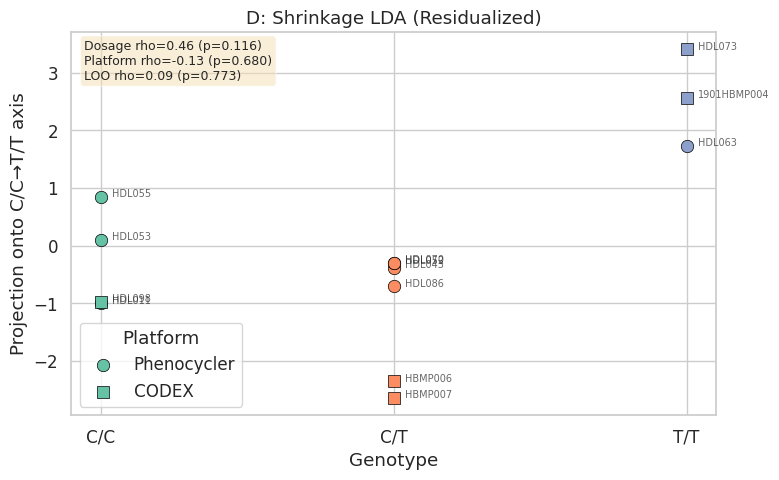

In [12]:
proj_df_shrink = pd.DataFrame({
    'Sample': samples_all, 'Projection': projs_shrink,
    'Genotype': genos_all, 'Platform': plats_all,
})

fig, ax = plt.subplots(figsize=(8, 5))
plot_projection(proj_df_shrink, 'D: Shrinkage LDA (Residualized)', ax=ax)
ax.text(0.02, 0.98,
    f'Dosage rho={rho_d_s:.2f} (p={p_d_s:.3f})\n'
    f'Platform rho={rho_pl_s:.2f} (p={p_pl_s:.3f})\n'
    f'LOO rho={rho_loo_s:.2f} (p={p_loo_s:.3f})',
    transform=ax.transAxes, fontsize=9, va='top',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
fig.tight_layout()
save_figure(fig, 'H11_shrinkage_lda')
plt.show()

## Section 6: Approach E — Single-Cell Derived Features

In [13]:
# Define columns to load from Cells.csv
CELLS_CSV = PROJECT / 'Measurements' / 'Cells.csv'

COMMON_MARKERS = [
    'DAPI', 'CD45RO', 'Ki67', 'CD20', 'CD4', 'CD44', 'CD31', 'CD11c',
    'CD34', 'CD107a', 'CD163', 'HLA-DR', 'CD68', 'CD8', 'CD21',
    'Vimentin', 'CD3e', 'CD45', 'Podoplanin',
]
MARKER_COLS = [f'Cell: {m}: Mean' for m in COMMON_MARKERS]
DIST_COLS = [
    'Signed distance to annotation Follicle µm',
    'Signed distance to annotation PALS µm',
    'Signed distance to annotation RedPulp µm',
]
USE_COLS = ['Image'] + MARKER_COLS + DIST_COLS

# Cell-type marker definitions (marker → cell type)
CELL_TYPES = {
    'CD20': 'B_cell', 'CD3e': 'T_cell', 'CD4': 'T_helper',
    'CD8': 'T_cytotoxic', 'CD68': 'Macrophage', 'CD11c': 'DC',
    'CD31': 'Endothelial', 'CD21': 'FDC',
}
CT_MARKER_COLS = [f'Cell: {m}: Mean' for m in CELL_TYPES.keys()]

REGIONS_SC = ['Follicle', 'PALS', 'RedPulp']

print(f'Will load {len(USE_COLS)} columns from Cells.csv')
print(f'Cell types: {list(CELL_TYPES.values())}')

Will load 23 columns from Cells.csv
Cell types: ['B_cell', 'T_cell', 'T_helper', 'T_cytotoxic', 'Macrophage', 'DC', 'Endothelial', 'FDC']


In [14]:
%%time
# Pass 1: sample 10% of cells per image to compute 75th percentile thresholds
print('Pass 1: Computing per-image 75th percentile thresholds...')
threshold_samples = {}
chunk_iter = pd.read_csv(CELLS_CSV, usecols=USE_COLS, chunksize=500_000)
for i, chunk in enumerate(chunk_iter):
    if i % 10 == 0:
        print(f'  Pass 1 chunk {i}...', flush=True)
    chunk['Sample'] = chunk['Image'].apply(extract_sample_id)
    chunk = chunk[~chunk['Sample'].isin(EXCLUDE_SAMPLES)]
    chunk = chunk[chunk['Sample'].map(GENOTYPE_MAP).notna()]
    # Sample 10%
    sampled = chunk.sample(frac=0.1, random_state=42)
    for sid, grp in sampled.groupby('Sample'):
        if sid not in threshold_samples:
            threshold_samples[sid] = []
        threshold_samples[sid].append(grp[CT_MARKER_COLS].values)

# Compute 75th percentile per image per cell-type marker
thresholds = {}  # {sample: {marker_col: threshold}}
for sid, arrays in threshold_samples.items():
    combined = np.vstack(arrays)
    thresholds[sid] = {}
    for j, col in enumerate(CT_MARKER_COLS):
        thresholds[sid][col] = np.nanpercentile(combined[:, j], 75)

print(f'Computed thresholds for {len(thresholds)} samples')
del threshold_samples  # free memory

Pass 1: Computing per-image 75th percentile thresholds...


  Pass 1 chunk 0...


  Pass 1 chunk 10...


  Pass 1 chunk 20...


  Pass 1 chunk 30...


  Pass 1 chunk 40...


Computed thresholds for 11 samples
CPU times: user 1min 2s, sys: 5.89 s, total: 1min 7s
Wall time: 1min 7s


In [15]:
%%time
# Pass 2: full accumulation — per-sample/per-region counts, sums, cell-type positives
print('Pass 2: Full accumulation...')

# Accumulators: {(sample, region): {'count': int, 'sums': array, 'ct_pos': dict}}
accum = {}

def init_accum(key):
    accum[key] = {
        'count': 0,
        'sums': np.zeros(len(MARKER_COLS)),
        'ct_pos': {ct: 0 for ct in CELL_TYPES.values()},
    }

chunk_iter = pd.read_csv(CELLS_CSV, usecols=USE_COLS, chunksize=500_000)
for i, chunk in enumerate(chunk_iter):
    if i % 10 == 0:
        print(f'  Pass 2 chunk {i}...', flush=True)
    chunk['Sample'] = chunk['Image'].apply(extract_sample_id)
    chunk = chunk[~chunk['Sample'].isin(EXCLUDE_SAMPLES)]
    chunk = chunk[chunk['Sample'].map(GENOTYPE_MAP).notna()]
    if chunk.empty:
        continue

    # Assign region by signed distance
    regions = assign_region_by_distance(
        chunk[DIST_COLS[0]].values,
        chunk[DIST_COLS[1]].values,
        chunk[DIST_COLS[2]].values,
    )
    chunk['Region'] = regions
    # Only keep Follicle, PALS, RedPulp
    chunk = chunk[chunk['Region'].isin(REGIONS_SC)]
    if chunk.empty:
        continue

    marker_vals = chunk[MARKER_COLS].values

    for (sid, reg), grp in chunk.groupby(['Sample', 'Region']):
        key = (sid, reg)
        if key not in accum:
            init_accum(key)
        idx = grp.index
        n = len(idx)
        accum[key]['count'] += n
        grp_markers = marker_vals[chunk.index.get_indexer(idx)]
        accum[key]['sums'] += np.nansum(grp_markers, axis=0)

        # Cell-type positives
        if sid in thresholds:
            for marker, ct_name in CELL_TYPES.items():
                mcol = f'Cell: {marker}: Mean'
                col_idx = CT_MARKER_COLS.index(mcol)
                vals = grp_markers[:, MARKER_COLS.index(mcol)]
                thr = thresholds[sid][mcol]
                accum[key]['ct_pos'][ct_name] += int(np.nansum(vals > thr))

print(f'Accumulated {len(accum)} (sample, region) groups')

Pass 2: Full accumulation...


  Pass 2 chunk 0...


  Pass 2 chunk 10...


  Pass 2 chunk 20...


  Pass 2 chunk 30...


  Pass 2 chunk 40...


Accumulated 33 (sample, region) groups
CPU times: user 1min 7s, sys: 10.6 s, total: 1min 18s
Wall time: 1min 18s


In [16]:
# Build single-cell feature matrix
sc_records = []
all_sc_samples = sorted(set(k[0] for k in accum.keys()))

for sid in all_sc_samples:
    rec = {'Sample': sid}
    total_cells = sum(accum.get((sid, r), {}).get('count', 0) for r in REGIONS_SC)
    if total_cells == 0:
        continue

    for reg in REGIONS_SC:
        key = (sid, reg)
        n = accum.get(key, {}).get('count', 0)
        rec[f'{reg}_cell_fraction'] = n / total_cells if total_cells > 0 else 0

        # Cell-type fractions
        for ct_name in CELL_TYPES.values():
            pos = accum.get(key, {}).get('ct_pos', {}).get(ct_name, 0)
            rec[f'{ct_name}_{reg}_fraction'] = pos / n if n > 0 else 0

        # Marker means
        for j, marker in enumerate(COMMON_MARKERS):
            s = accum.get(key, {}).get('sums', np.zeros(len(MARKER_COLS)))
            rec[f'{marker}_{reg}_mean'] = s[j] / n if n > 0 else 0

    sc_records.append(rec)

sc_feat = pd.DataFrame(sc_records).set_index('Sample')
sc_feat['Genotype'] = sc_feat.index.map(GENOTYPE_MAP)
sc_feat['Platform'] = sc_feat.index.map(
    lambda s: 'CODEX' if s in CODEX_SAMPLES else 'Phenocycler')
sc_feat = sc_feat.dropna(subset=['Genotype'])
sc_feat['Genotype'] = pd.Categorical(sc_feat['Genotype'], categories=GENO_ORDER, ordered=True)

sc_morph_cols = [c for c in sc_feat.columns if c not in ('Genotype', 'Platform')]

# Filter: variance > 0 and platform-clean (p > 0.1)
var_mask = sc_feat[sc_morph_cols].var() > 0
sc_morph_cols = [c for c in sc_morph_cols if var_mask[c]]

sc_plat_diag = platform_diagnostic(sc_feat, sc_morph_cols)
sc_clean = sc_plat_diag.loc[sc_plat_diag['p'] > 0.1, 'Feature'].tolist()
print(f'SC features: {len(sc_morph_cols)} total, {len(sc_clean)} platform-clean')

save_table(sc_feat.reset_index(), 'H11_singlecell_features')
print(f'Samples in SC data: {len(sc_feat)}')
sc_feat[['Genotype', 'Platform']].value_counts()

SC features: 84 total, 36 platform-clean
Saved: analysis/tables/H11_singlecell_features.csv
Samples in SC data: 11


Genotype  Platform   
C/T       Phenocycler    5
C/C       Phenocycler    3
T/T       CODEX          2
          Phenocycler    1
Name: count, dtype: int64

In [17]:
# Single-cell LDA
use_sc_cols = sc_clean if len(sc_clean) >= 2 else sc_morph_cols
print(f'Using {len(use_sc_cols)} SC features for LDA')

# Fill any NaN with column median
sc_feat_filled = sc_feat.copy()
for col in use_sc_cols:
    if sc_feat_filled[col].isna().any():
        sc_feat_filled[col] = sc_feat_filled[col].fillna(sc_feat_filled[col].median())

X_sc_raw = sc_feat_filled[use_sc_cols].values.astype(float)
scaler_sc = StandardScaler()
X_sc = scaler_sc.fit_transform(X_sc_raw)
genos_sc = sc_feat_filled['Genotype'].astype(str).values
plats_sc = sc_feat_filled['Platform'].values
samples_sc = sc_feat_filled.index.values

# Centroid axis
projs_sc = None
if 'C/C' in genos_sc and 'T/T' in genos_sc:
    axis_sc = centroid_axis(X_sc, genos_sc)
    projs_sc = X_sc @ axis_sc
    rho_d_sc, p_d_sc = dosage_rho(projs_sc, genos_sc)
    rho_pl_sc, p_pl_sc = platform_rho(projs_sc, plats_sc)
    rho_loo_sc, p_loo_sc = loo_dosage_rho(X_sc, genos_sc)
    print(f'SC Centroid LDA:')
    print(f'  Dosage rho={rho_d_sc:.3f} (p={p_d_sc:.3f})')
    print(f'  Platform rho={rho_pl_sc:.3f} (p={p_pl_sc:.3f})')
    print(f'  LOO rho={rho_loo_sc:.3f} (p={p_loo_sc:.3f})')

# Shrinkage LDA on SC (eigen solver, n_components=1)
y_sc = np.array([DOSAGE_MAP[g] for g in genos_sc])
lda_sc = LinearDiscriminantAnalysis(solver='eigen', shrinkage='auto', n_components=1)
lda_sc.fit(X_sc, y_sc)
projs_sc_shrink = lda_sc.transform(X_sc).ravel()
if np.corrcoef(y_sc, projs_sc_shrink)[0, 1] < 0:
    projs_sc_shrink = -projs_sc_shrink

rho_d_scs, p_d_scs = dosage_rho(projs_sc_shrink, genos_sc)
rho_pl_scs, p_pl_scs = platform_rho(projs_sc_shrink, plats_sc)

print(f'\nSC Shrinkage LDA:')
print(f'  Dosage rho={rho_d_scs:.3f} (p={p_d_scs:.3f})')
print(f'  Platform rho={rho_pl_scs:.3f} (p={p_pl_scs:.3f})')

Using 36 SC features for LDA
SC Centroid LDA:
  Dosage rho=0.778 (p=0.005)
  Platform rho=0.671 (p=0.024)
  LOO rho=-0.623 (p=0.041)

SC Shrinkage LDA:
  Dosage rho=0.623 (p=0.041)
  Platform rho=0.671 (p=0.024)


Saved: analysis/figures/H11_singlecell_lda.png


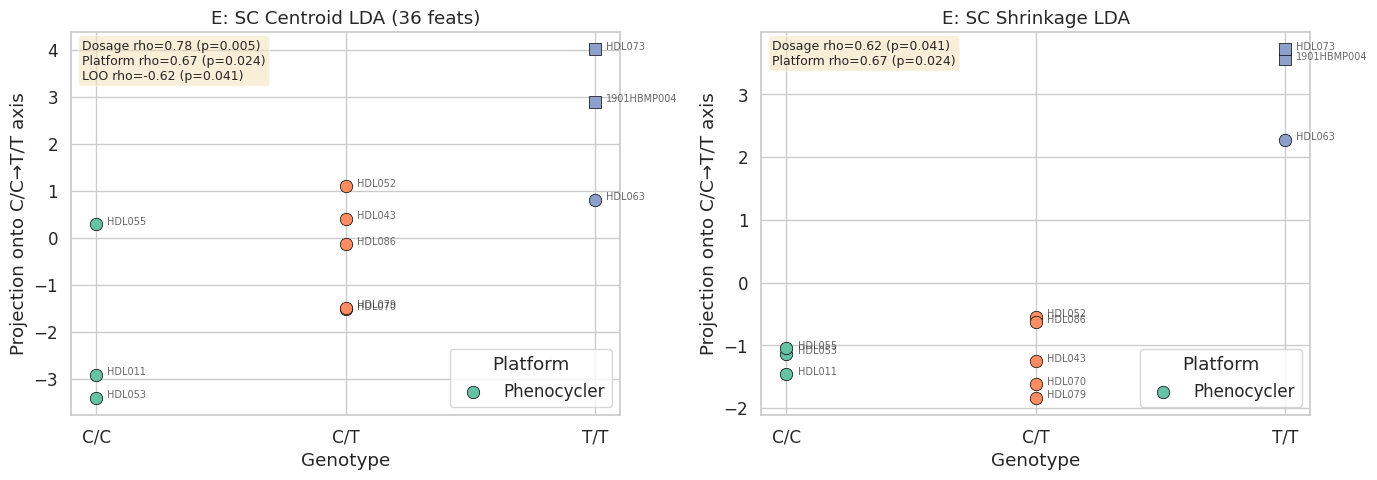

In [18]:
if projs_sc is not None:
    proj_df_sc = pd.DataFrame({
        'Sample': samples_sc, 'Projection': projs_sc,
        'Genotype': genos_sc, 'Platform': plats_sc,
    })
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    plot_projection(proj_df_sc, f'E: SC Centroid LDA ({len(use_sc_cols)} feats)', ax=axes[0])
    axes[0].text(0.02, 0.98,
        f'Dosage rho={rho_d_sc:.2f} (p={p_d_sc:.3f})\n'
        f'Platform rho={rho_pl_sc:.2f} (p={p_pl_sc:.3f})\n'
        f'LOO rho={rho_loo_sc:.2f} (p={p_loo_sc:.3f})',
        transform=axes[0].transAxes, fontsize=9, va='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    proj_df_scs = pd.DataFrame({
        'Sample': samples_sc, 'Projection': projs_sc_shrink,
        'Genotype': genos_sc, 'Platform': plats_sc,
    })
    plot_projection(proj_df_scs, 'E: SC Shrinkage LDA', ax=axes[1])
    axes[1].text(0.02, 0.98,
        f'Dosage rho={rho_d_scs:.2f} (p={p_d_scs:.3f})\n'
        f'Platform rho={rho_pl_scs:.2f} (p={p_pl_scs:.3f})',
        transform=axes[1].transAxes, fontsize=9, va='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    fig.tight_layout()
    save_figure(fig, 'H11_singlecell_lda')
    plt.show()

## Section 7: Permutation & Bootstrap Testing

In [19]:
%%time
N_PERM = 10_000
N_BOOT = 5_000

def permutation_test(X, genotypes, n_perm=N_PERM, method='centroid'):
    """Permutation test: shuffle genotype labels, recompute axis + dosage rho."""
    null_rhos = np.zeros(n_perm)
    for k in range(n_perm):
        g_perm = rng.permutation(genotypes)
        try:
            if method == 'centroid':
                ax = centroid_axis(X, g_perm)
                proj = X @ ax
            else:  # shrinkage
                y_perm = np.array([DOSAGE_MAP[g] for g in g_perm])
                lda = LinearDiscriminantAnalysis(solver='eigen', shrinkage='auto', n_components=1)
                lda.fit(X, y_perm)
                proj = lda.transform(X).ravel()
            dosage = np.array([DOSAGE_MAP[g] for g in g_perm])
            null_rhos[k] = spearmanr(dosage, proj).statistic
        except Exception:
            null_rhos[k] = np.nan
    return null_rhos


def bootstrap_ci(X, genotypes, n_boot=N_BOOT, method='centroid'):
    """Bootstrap 95% CI for dosage rho."""
    boot_rhos = np.zeros(n_boot)
    n = len(X)
    for k in range(n_boot):
        idx = rng.choice(n, size=n, replace=True)
        X_b = X[idx]
        g_b = genotypes[idx]
        # Need at least 1 of each group
        if len(set(g_b)) < 2 or 'C/C' not in g_b or 'T/T' not in g_b:
            boot_rhos[k] = np.nan
            continue
        try:
            if method == 'centroid':
                ax = centroid_axis(X_b, g_b)
                proj = X_b @ ax
            else:
                y_b = np.array([DOSAGE_MAP[g] for g in g_b])
                lda = LinearDiscriminantAnalysis(solver='eigen', shrinkage='auto', n_components=1)
                lda.fit(X_b, y_b)
                proj = lda.transform(X_b).ravel()
            dosage = np.array([DOSAGE_MAP[g] for g in g_b])
            boot_rhos[k] = spearmanr(dosage, proj).statistic
        except Exception:
            boot_rhos[k] = np.nan
    valid = boot_rhos[~np.isnan(boot_rhos)]
    return np.percentile(valid, [2.5, 97.5]) if len(valid) > 0 else (np.nan, np.nan)


# Run permutation + bootstrap for each approach
approaches = {
    'Baseline': (X_all, genos_all, projs_all, 'centroid'),
    'A_Residualized': (X_resid, genos_all, projs_resid, 'centroid'),
    'D_Shrinkage': (X_resid, genos_all, projs_shrink, 'shrinkage'),
}
if projs_clean is not None:
    approaches['C_Clean'] = (X_clean, genos_all, projs_clean, 'centroid')
if projs_sc is not None:
    approaches['E_SingleCell'] = (X_sc, genos_sc, projs_sc, 'centroid')

perm_results = {}
for name, (X_ap, g_ap, p_ap, method) in approaches.items():
    print(f'Permutation + bootstrap: {name}...')
    null = permutation_test(X_ap, g_ap, method=method)
    obs_rho = dosage_rho(p_ap, g_ap)[0]
    p_perm = np.mean(np.abs(null[~np.isnan(null)]) >= abs(obs_rho))
    ci = bootstrap_ci(X_ap, g_ap, method=method)
    perm_results[name] = {
        'obs_rho': obs_rho, 'p_perm': p_perm,
        'ci_lo': ci[0], 'ci_hi': ci[1], 'null': null,
    }
    print(f'  obs_rho={obs_rho:.3f}, p_perm={p_perm:.4f}, CI=[{ci[0]:.3f}, {ci[1]:.3f}]')

Permutation + bootstrap: Baseline...


  obs_rho=0.478, p_perm=0.8923, CI=[0.297, 0.938]
Permutation + bootstrap: A_Residualized...


  obs_rho=0.496, p_perm=0.8678, CI=[0.203, 0.916]
Permutation + bootstrap: D_Shrinkage...


/home/smith6jt/.local/lib/python3.12/site-packages/sklearn/covariance/_shrunk_covariance.py:349: UserWarning: Only one sample available. You may want to reshape your data array
  warnings.warn(
/home/smith6jt/.local/lib/python3.12/site-packages/sklearn/covariance/_empirical_covariance.py:100: UserWarning: Only one sample available. You may want to reshape your data array
  warnings.warn(
/home/smith6jt/.local/lib/python3.12/site-packages/sklearn/covariance/_shrunk_covariance.py:349: UserWarning: Only one sample available. You may want to reshape your data array
  warnings.warn(
/home/smith6jt/.local/lib/python3.12/site-packages/sklearn/covariance/_empirical_covariance.py:100: UserWarning: Only one sample available. You may want to reshape your data array
  warnings.warn(
/home/smith6jt/.local/lib/python3.12/site-packages/sklearn/covariance/_shrunk_covariance.py:349: UserWarning: Only one sample available. You may want to reshape your data array
  warnings.warn(
/home/smith6jt/.local/li

/home/smith6jt/.local/lib/python3.12/site-packages/sklearn/covariance/_shrunk_covariance.py:349: UserWarning: Only one sample available. You may want to reshape your data array
  warnings.warn(
/home/smith6jt/.local/lib/python3.12/site-packages/sklearn/covariance/_empirical_covariance.py:100: UserWarning: Only one sample available. You may want to reshape your data array
  warnings.warn(
/home/smith6jt/.local/lib/python3.12/site-packages/sklearn/covariance/_shrunk_covariance.py:349: UserWarning: Only one sample available. You may want to reshape your data array
  warnings.warn(
/home/smith6jt/.local/lib/python3.12/site-packages/sklearn/covariance/_empirical_covariance.py:100: UserWarning: Only one sample available. You may want to reshape your data array
  warnings.warn(
/home/smith6jt/.local/lib/python3.12/site-packages/sklearn/covariance/_shrunk_covariance.py:349: UserWarning: Only one sample available. You may want to reshape your data array
  warnings.warn(
/home/smith6jt/.local/li

...

/home/smith6jt/.local/lib/python3.12/site-packages/sklearn/covariance/_shrunk_covariance.py:349: UserWarning: Only one sample available. You may want to reshape your data array
  warnings.warn(
/home/smith6jt/.local/lib/python3.12/site-packages/sklearn/covariance/_empirical_covariance.py:100: UserWarning: Only one sample available. You may want to reshape your data array
  warnings.warn(
/home/smith6jt/.local/lib/python3.12/site-packages/sklearn/covariance/_shrunk_covariance.py:349: UserWarning: Only one sample available. You may want to reshape your data array
  warnings.warn(
/home/smith6jt/.local/lib/python3.12/site-packages/sklearn/covariance/_empirical_covariance.py:100: UserWarning: Only one sample available. You may want to reshape your data array
  warnings.warn(
/home/smith6jt/.local/lib/python3.12/site-packages/sklearn/covariance/_shrunk_covariance.py:349: UserWarning: Only one sample available. You may want to reshape your data array
  warnings.warn(
/home/smith6jt/.local/li

/home/smith6jt/.local/lib/python3.12/site-packages/sklearn/covariance/_shrunk_covariance.py:349: UserWarning: Only one sample available. You may want to reshape your data array
  warnings.warn(
/home/smith6jt/.local/lib/python3.12/site-packages/sklearn/covariance/_empirical_covariance.py:100: UserWarning: Only one sample available. You may want to reshape your data array
  warnings.warn(
/home/smith6jt/.local/lib/python3.12/site-packages/sklearn/covariance/_shrunk_covariance.py:349: UserWarning: Only one sample available. You may want to reshape your data array
  warnings.warn(
/home/smith6jt/.local/lib/python3.12/site-packages/sklearn/covariance/_empirical_covariance.py:100: UserWarning: Only one sample available. You may want to reshape your data array
  warnings.warn(
/home/smith6jt/.local/lib/python3.12/site-packages/sklearn/covariance/_shrunk_covariance.py:349: UserWarning: Only one sample available. You may want to reshape your data array
  warnings.warn(
/home/smith6jt/.local/li

  obs_rho=0.458, p_perm=0.5747, CI=[-0.945, 0.946]
Permutation + bootstrap: C_Clean...


  obs_rho=0.499, p_perm=0.7919, CI=[0.186, 0.930]
Permutation + bootstrap: E_SingleCell...


  obs_rho=0.778, p_perm=0.3645, CI=[0.363, 0.950]
CPU times: user 40.7 s, sys: 24.6 ms, total: 40.7 s
Wall time: 40.7 s


Saved: analysis/figures/H11_permutation_null.png
Saved: analysis/tables/H11_permutation_results.csv


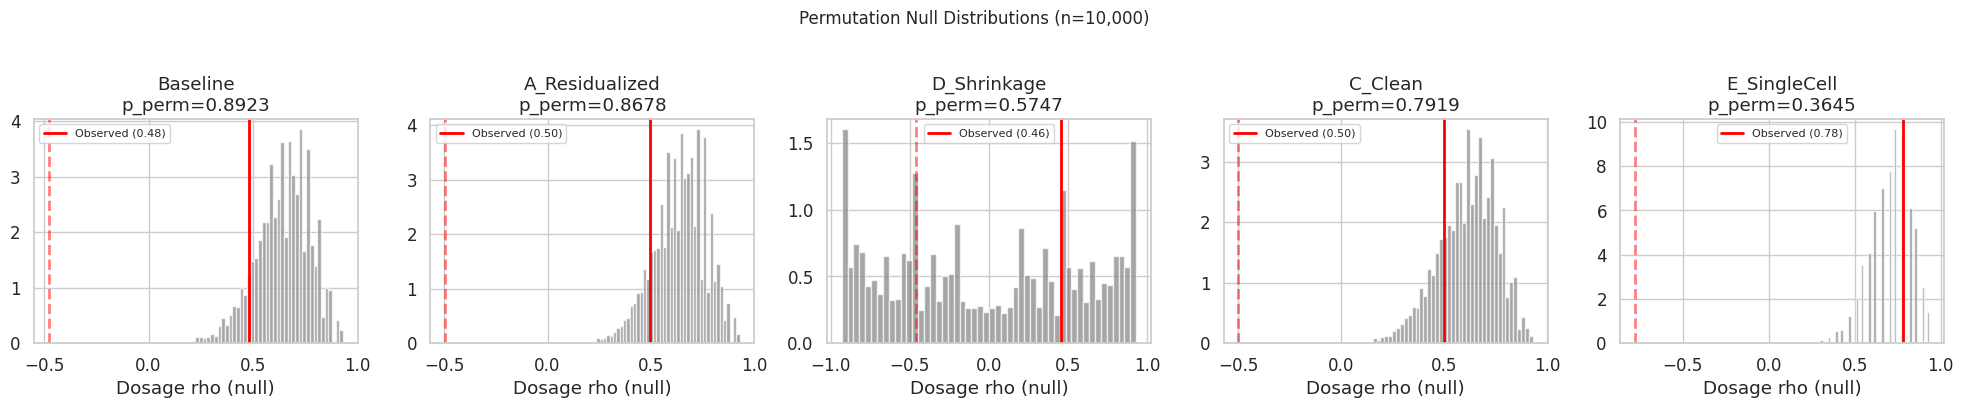

,Approach,obs_rho,p_perm,bootstrap_CI_lo,bootstrap_CI_hi
0,Baseline,0.478420,0.8923,0.296696,0.938024
1,A_Residualized,0.496139,0.8678,0.203030,0.915960
2,D_Shrinkage,0.457747,0.5747,-0.945439,0.945984
3,C_Clean,0.499092,0.7919,0.186339,0.930406
4,E_SingleCell,0.778499,0.3645,0.363213,0.950382


In [20]:
# Permutation null distribution figure
n_panels = len(perm_results)
fig, axes = plt.subplots(1, n_panels, figsize=(4 * n_panels, 4), squeeze=False)
axes = axes.ravel()

for i, (name, res) in enumerate(perm_results.items()):
    null = res['null'][~np.isnan(res['null'])]
    axes[i].hist(null, bins=50, color='gray', alpha=0.7, density=True)
    axes[i].axvline(res['obs_rho'], color='red', linewidth=2, label=f'Observed ({res["obs_rho"]:.2f})')
    axes[i].axvline(-res['obs_rho'], color='red', linewidth=2, linestyle='--', alpha=0.5)
    axes[i].set_title(f'{name}\np_perm={res["p_perm"]:.4f}')
    axes[i].set_xlabel('Dosage rho (null)')
    axes[i].legend(fontsize=8)

fig.suptitle('Permutation Null Distributions (n=10,000)', fontsize=12, y=1.02)
fig.tight_layout()
save_figure(fig, 'H11_permutation_null')

# Save permutation results table
perm_df = pd.DataFrame([
    {'Approach': name, 'obs_rho': r['obs_rho'], 'p_perm': r['p_perm'],
     'bootstrap_CI_lo': r['ci_lo'], 'bootstrap_CI_hi': r['ci_hi']}
    for name, r in perm_results.items()
])
save_table(perm_df, 'H11_permutation_results')
plt.show()
perm_df

## Section 8: Integrated Summary

In [21]:
# Comparison table across all approaches
rows = []

def add_row(name, rho_d, rho_p, cos_pc, rho_l, p_perm, ci_lo, ci_hi, n):
    rows.append({
        'Approach': name,
        'rho_dosage': rho_d, 'rho_platform': rho_p,
        'cos_vs_pc_axis': cos_pc, 'rho_LOO': rho_l,
        'p_perm': p_perm,
        'bootstrap_CI': f'[{ci_lo:.2f}, {ci_hi:.2f}]' if not np.isnan(ci_lo) else '',
        'n_samples': n,
    })

pr = perm_results
add_row('Baseline', rho_d, rho_pl, cos_all_pc, rho_loo,
        pr['Baseline']['p_perm'], pr['Baseline']['ci_lo'], pr['Baseline']['ci_hi'], len(X_all))
add_row('A: Residualized', rho_d_r, rho_pl_r, cos_resid_pc, rho_loo_r,
        pr['A_Residualized']['p_perm'], pr['A_Residualized']['ci_lo'], pr['A_Residualized']['ci_hi'], len(X_all))
add_row('B: PC-Only', rho_d_pc, rho_pl_pc, 1.0, rho_loo_pc,
        np.nan, np.nan, np.nan, len(X_all))  # No permutation for B (axis is fixed)
if projs_clean is not None:
    add_row('C: Clean Features', rho_d_c, rho_pl_c, cos_clean_pc, rho_loo_c,
            pr.get('C_Clean', {}).get('p_perm', np.nan),
            pr.get('C_Clean', {}).get('ci_lo', np.nan),
            pr.get('C_Clean', {}).get('ci_hi', np.nan), len(X_all))
add_row('D: Shrinkage', rho_d_s, rho_pl_s, cos_shrink_pc, rho_loo_s,
        pr['D_Shrinkage']['p_perm'], pr['D_Shrinkage']['ci_lo'], pr['D_Shrinkage']['ci_hi'], len(X_all))
if projs_sc is not None:
    add_row('E: Single-Cell', rho_d_sc, rho_pl_sc, np.nan, rho_loo_sc,
            pr.get('E_SingleCell', {}).get('p_perm', np.nan),
            pr.get('E_SingleCell', {}).get('ci_lo', np.nan),
            pr.get('E_SingleCell', {}).get('ci_hi', np.nan), len(X_sc))

comparison = pd.DataFrame(rows)
save_table(comparison, 'H11_approach_comparison')
comparison

Saved: analysis/tables/H11_approach_comparison.csv


,Approach,rho_dosage,rho_platform,cos_vs_pc_axis,rho_LOO,p_perm,bootstrap_CI,n_samples
0,Baseline,0.478420,0.464835,-0.104033,0.129941,0.8923,"[0.30, 0.94]",13
1,A: Residualized,0.496139,-0.169031,0.056493,0.180146,0.8678,"[0.20, 0.92]",13
2,B: PC-Only,-0.109269,-0.591608,1.000000,NaN,NaN,,13
3,C: Clean Features,0.499092,0.211289,-0.002837,0.183099,0.7919,"[0.19, 0.93]",13
4,D: Shrinkage,0.457747,-0.126773,-0.478859,0.088596,0.5747,"[-0.95, 0.95]",13
5,E: Single-Cell,0.778499,0.670820,NaN,-0.622799,0.3645,"[0.36, 0.95]",11


Saved: analysis/figures/H11_approach_comparison.png


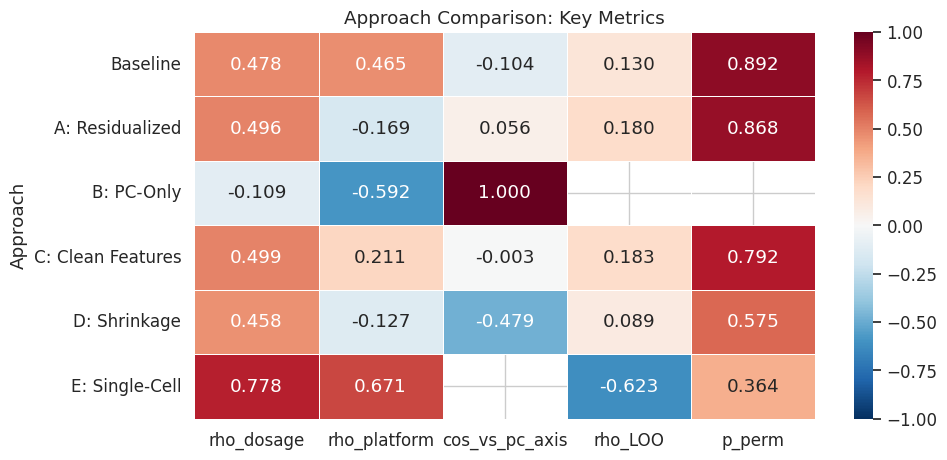

In [22]:
# Comparison heatmap figure
metric_cols = ['rho_dosage', 'rho_platform', 'cos_vs_pc_axis', 'rho_LOO', 'p_perm']
plot_data = comparison.set_index('Approach')[metric_cols].apply(pd.to_numeric, errors='coerce')

fig, ax = plt.subplots(figsize=(10, max(4, len(plot_data) * 0.8)))
sns.heatmap(plot_data, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Approach Comparison: Key Metrics')
fig.tight_layout()
save_figure(fig, 'H11_approach_comparison')
plt.show()

Saved: analysis/tables/H11_feature_concordance.csv


Saved: analysis/figures/H11_feature_concordance.png


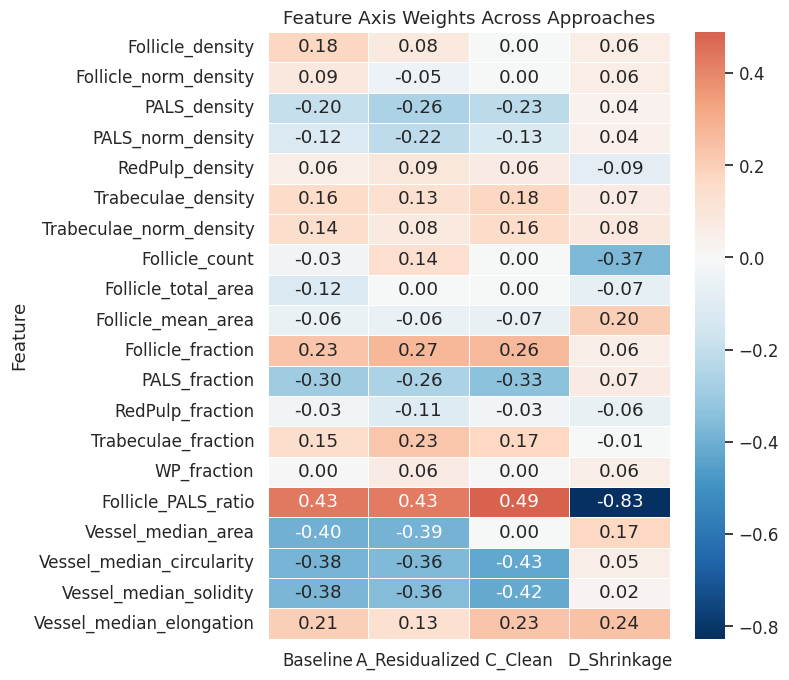

In [23]:
# Feature concordance: which features drive the axis across approaches?
axis_dict = {'Baseline': (axis_all, morph_cols)}
axis_dict['A_Residualized'] = (axis_resid, morph_cols)
if projs_clean is not None:
    # Pad clean axis to full feature set
    full_clean = np.zeros(len(morph_cols))
    for j, c in enumerate(clean_features):
        full_clean[morph_cols.index(c)] = axis_clean[j]
    axis_dict['C_Clean'] = (full_clean, morph_cols)

# Shrinkage axis (from scalings_)
axis_dict['D_Shrinkage'] = (shrink_axis_norm, morph_cols)

# Build weight matrix
concordance_data = pd.DataFrame(index=morph_cols)
for name, (ax_vec, cols) in axis_dict.items():
    concordance_data[name] = ax_vec

save_table(concordance_data.reset_index().rename(columns={'index': 'Feature'}),
           'H11_feature_concordance')

fig, ax = plt.subplots(figsize=(8, max(6, len(morph_cols) * 0.35)))
sns.heatmap(concordance_data, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            linewidths=0.5, ax=ax)
ax.set_title('Feature Axis Weights Across Approaches')
ax.set_ylabel('Feature')
fig.tight_layout()
save_figure(fig, 'H11_feature_concordance')
plt.show()

In [24]:
# Collect all stats into one table
stat_rows = []
stat_rows.append({'Test': 'Baseline centroid', 'rho_dosage': rho_d, 'p_dosage': p_d,
                  'rho_platform': rho_pl, 'p_platform': p_pl, 'rho_LOO': rho_loo, 'p_LOO': p_loo})
stat_rows.append({'Test': 'A: Residualized', 'rho_dosage': rho_d_r, 'p_dosage': p_d_r,
                  'rho_platform': rho_pl_r, 'p_platform': p_pl_r, 'rho_LOO': rho_loo_r, 'p_LOO': p_loo_r})
stat_rows.append({'Test': 'B: PC-Only axis', 'rho_dosage': rho_d_pc, 'p_dosage': p_d_pc,
                  'rho_platform': rho_pl_pc, 'p_platform': p_pl_pc, 'rho_LOO': rho_loo_pc, 'p_LOO': p_loo_pc})
if projs_clean is not None:
    stat_rows.append({'Test': 'C: Clean features', 'rho_dosage': rho_d_c, 'p_dosage': p_d_c,
                      'rho_platform': rho_pl_c, 'p_platform': p_pl_c, 'rho_LOO': rho_loo_c, 'p_LOO': p_loo_c})
stat_rows.append({'Test': 'D: Shrinkage LDA', 'rho_dosage': rho_d_s, 'p_dosage': p_d_s,
                  'rho_platform': rho_pl_s, 'p_platform': p_pl_s, 'rho_LOO': rho_loo_s, 'p_LOO': p_loo_s})
if projs_sc is not None:
    stat_rows.append({'Test': 'E: Single-cell', 'rho_dosage': rho_d_sc, 'p_dosage': p_d_sc,
                      'rho_platform': rho_pl_sc, 'p_platform': p_pl_sc, 'rho_LOO': rho_loo_sc, 'p_LOO': p_loo_sc})

stats_df = pd.DataFrame(stat_rows)
save_table(stats_df, 'H11_statistical_tests')
stats_df

Saved: analysis/tables/H11_statistical_tests.csv


,Test,rho_dosage,p_dosage,rho_platform,p_platform,rho_LOO,p_LOO
0,Baseline centroid,0.478420,0.098170,0.464835,0.109499,0.129941,0.672219
1,A: Residualized,0.496139,0.084633,-0.169031,0.580921,0.180146,0.555908
2,B: PC-Only axis,-0.109269,0.722332,-0.591608,0.033189,NaN,NaN
3,C: Clean features,0.499092,0.082510,0.211289,0.488349,0.183099,0.549339
4,D: Shrinkage LDA,0.457747,0.115747,-0.126773,0.679824,0.088596,0.773487
5,E: Single-cell,0.778499,0.004763,0.670820,0.023856,-0.622799,0.040685


In [25]:
# Key findings summary
print('=' * 70)
print('H11 KEY FINDINGS: Platform-Deconfounded LDA')
print('=' * 70)
print()
print('BASELINE CONTAMINATION:')
print(f'  In-sample dosage rho = {rho_d:.3f} (p={p_d:.3f})')
print(f'  Platform rho = {rho_pl:.3f} (p={p_pl:.3f})')
print(f'  LOO dosage rho = {rho_loo:.3f} (p={p_loo:.3f})')
print(f'  Cos(All, PC-only axis) = {cos_all_pc:.3f}')
print(f'  Permutation p = {perm_results["Baseline"]["p_perm"]:.4f}')
print()
print('DECONFOUNDED RESULTS:')
for _, row in comparison.iterrows():
    if row['Approach'] == 'Baseline':
        continue
    print(f'  {row["Approach"]}:')
    print(f'    dosage rho={row["rho_dosage"]:.3f}, platform rho={row["rho_platform"]:.3f}, '
          f'LOO={row["rho_LOO"]:.3f}')
    if pd.notna(row.get('p_perm')):
        print(f'    p_perm={row["p_perm"]:.4f}, CI={row["bootstrap_CI"]}')
print()
print('INTERPRETATION:')
# Check if any deconfounded approach survives
surviving = comparison[
    (comparison['Approach'] != 'Baseline') &
    (comparison['p_perm'].apply(lambda x: pd.notna(x) and x < 0.05))
]
if len(surviving) > 0:
    print(f'  {len(surviving)} approach(es) survive permutation (p < 0.05):')
    for _, row in surviving.iterrows():
        print(f'    {row["Approach"]}: rho={row["rho_dosage"]:.3f}, p_perm={row["p_perm"]:.4f}')
    print('  → Evidence for biological genotype signal beyond platform artifact')
else:
    print('  No deconfounded approach survives permutation at p < 0.05')
    borderline = comparison[
        (comparison['Approach'] != 'Baseline') &
        (comparison['p_perm'].apply(lambda x: pd.notna(x) and x < 0.1))
    ]
    if len(borderline) > 0:
        print(f'  {len(borderline)} approach(es) borderline (p < 0.1):')
        for _, row in borderline.iterrows():
            print(f'    {row["Approach"]}: rho={row["rho_dosage"]:.3f}, p_perm={row["p_perm"]:.4f}')
    print('  → Baseline LDA result likely driven by platform confound')
print()
print(f'Single-cell features processed: {len(use_sc_cols)} ({len(sc_clean)} platform-clean)')
print(f'Samples: {len(feat)} annotation-level, {len(sc_feat)} single-cell level')

H11 KEY FINDINGS: Platform-Deconfounded LDA

BASELINE CONTAMINATION:
  In-sample dosage rho = 0.478 (p=0.098)
  Platform rho = 0.465 (p=0.109)
  LOO dosage rho = 0.130 (p=0.672)
  Cos(All, PC-only axis) = -0.104
  Permutation p = 0.8923

DECONFOUNDED RESULTS:
  A: Residualized:
    dosage rho=0.496, platform rho=-0.169, LOO=0.180
    p_perm=0.8678, CI=[0.20, 0.92]
  B: PC-Only:
    dosage rho=-0.109, platform rho=-0.592, LOO=nan
  C: Clean Features:
    dosage rho=0.499, platform rho=0.211, LOO=0.183
    p_perm=0.7919, CI=[0.19, 0.93]
  D: Shrinkage:
    dosage rho=0.458, platform rho=-0.127, LOO=0.089
    p_perm=0.5747, CI=[-0.95, 0.95]
  E: Single-Cell:
    dosage rho=0.778, platform rho=0.671, LOO=-0.623
    p_perm=0.3645, CI=[0.36, 0.95]

INTERPRETATION:
  No deconfounded approach survives permutation at p < 0.05
  → Baseline LDA result likely driven by platform confound

Single-cell features processed: 36 (36 platform-clean)
Samples: 13 annotation-level, 11 single-cell level
